# Research Assistant : Built with Agent built with LLM , Parallelization, sub-graph, persistance, map-reduce

### Goal : Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

#### Research: Its leborious work and AI has a great potential to guide and assist with this.
However, raw AI output is useless and without customising it or factualizing it.

#### Customization:  removes nusance and factualizes on the intent. 

### Workflow:

`Source Selection :`
Users can choose any set of input sources for their research.

`Planning : `
Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
Human-in-the-loop will be used to refine these sub-topics before research begins.

`LLM Utilization: `
Each analyst will conduct in-depth interviews with an expert AI using the selected sources.
The interview will be a multi-turn conversation to extract detailed insights as shown in the STORM paper.
These interviews will be captured in a using sub-graphs with their internal state.

`Research Process: `
Experts will gather information to answer analyst questions in parallel.
And all interviews will be conducted simultaneously through map-reduce.

`Output Format:`
The gathered insights from each interview will be synthesized into a final report.
We'll use customizable prompts for the report, allowing for a flexible output format.



In [1]:
# set up environmnet
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
# creat llm
from google import genai
from langchain_google_genai import ChatGoogleGenerativeAI

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHlHCtpj0k8XNY4MnHhMAZeu/VHQpEXU+lIdegS4zpd6v+TjgdO8zplMmHl81L'}}]

In [3]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

### Create a graph with llm to create and assign analysts depending on the topic and subtopic and human feedback.

In [296]:
from typing_extensions import TypedDict, Annotated , List
from operator import add

# create pydantic analyst blueprint
from pydantic import BaseModel ,Field

class Analyst(BaseModel):
    name:str = Field(description="Name of the analyst.")
    role:str = Field(description="Role of the analyst in the context of the topic.",)
    affiliation:str = Field(description="Primary affiliation of the analyst.",)
    description: str = Field(description="Description of the analyst focus, concerns, and motives.",)

    @property
    def persona(self)->str:
        return f"Analyst Name:{self.name}\n Role:{self.role}\n Affiliation: {self.affiliation}\n Description: {self.description}\n"
    
# create aoverall class
class overallState(TypedDict):
    topic: str
    subtopics:List[str]
    max_analyst:int
    subtopic_feedback:str
    human_analyst_feedback: str
    analysts : List[Analyst] # List[Analyst.persona* max_analyst] / annotated for persistance


#wraper for generating a list of analysts for structured output (important)
class AnalystList(BaseModel):
    analysts: List[Analyst]

    

In [280]:
# create node functions
# blueprint for llm output
class subtopic(BaseModel):
    subtopic: List[str]

#create a node to ask user for a topic
def get_topic(state):
    topic = input("What Topic are you interested in exploring and generating a report on? We have expert Analysts team to genetate reports for you based on your topic.\n Your topic: ")
    return {'topic': topic }
    
# generate sub topics    
def get_subtopic(state:overallState):
    '''generate listof subtopics'''
    topic = state['topic'];
    sub_topic_prompt = f"create a list of 3 distinct subtopics for the topic:'{topic}' provided."
    response = llm.with_structured_output(subtopic).invoke(sub_topic_prompt)
    return {'subtopics': response.subtopic }

# subtopic refining before search
def Human_feedback_refine_Subtopic(state):
    print(f"Sub Topics are: {state['subtopics']}")
    subtopic_feedback = state.get('subtopic_feedback' , None)
    subtopic_feedback_prompt = f"based on the feedback given by the expert here:'{subtopic_feedback}', re-adjust and re-create subtopics {state['subtopics']} accordingly. Ensure utmost correspondance to the original Topic"
    response = llm.with_structured_output(subtopic).invoke(subtopic_feedback_prompt)
    return { 'subtopics': response.subtopic }

# create analysts
analyst_prompt = """You are AI Analytic supervisor who is tasked with creating expert AI analysts and and assigning role for each subtopic provided. 
    Create AI analyst personas while following the following instructions clearly.
    1. Review the main topic{topic} and the subtopics {sub_topics}
    2. Examin and consider any editorial Human feedback provided as a guide to create the analysts : {human_analyst_feedback}
    3. determine the most interesting theme for each subtopic based on the document and or feedback.
    5. Create and assign the best analyst for each subtopic and or theme selected. create {max_no} analysts.
    6. Names and roles must be globally unique across all subtopics or themes(examaple for names: Dr. Alia Bhat , Dr. Devesh Patel, Dr.Jassica etc).
    8. Analyst must be highly qualified and exceptional."""

from langchain_core.messages import SystemMessage , HumanMessage    
def create_analysts(state):
    '''create unique anlysts according to the blueprint'''
    
    sys_instr = SystemMessage(content= analyst_prompt.format(topic = state['topic'] , sub_topics = state['subtopics'] , human_analyst_feedback = state.get('human_analyst_feedback', None), max_no = state['max_analyst']))
    Human_instr = HumanMessage(content="Generate a set of analysts. Carefully follow the system intruction")
    
    #print(f"subtopics: {state['subtopics']}")   
    response = llm.with_structured_output(AnalystList).invoke([sys_instr] +[ Human_instr])
    print(f"Feedback : {state.get('human_analyst_feedback', None)}")
    return {'analysts': [response]}


# get human feedback on analyst selection
def analyst_feedback(state):
    ''' get feedbackon the analysts for enhancemeent and change'''
    print("Enter your feedback on the analyst assignment. specify any chnages.")
    pass

# continue to assign analyst
def continue_with_Feedback(state):
    ''' continue to create analyst node if feedback exists'''
    feedback = state.get('human_analyst_feedback' , None)
    if feedback:
        return 'create_analysts'

    return END    

##### build graph

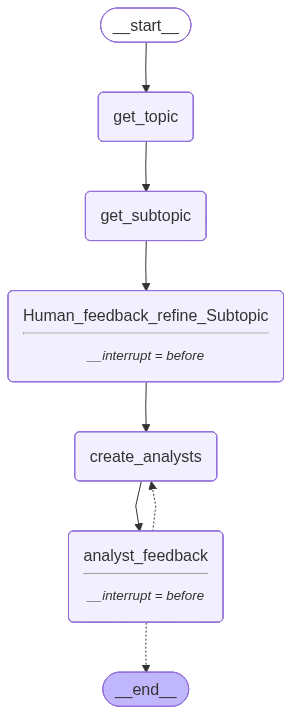

In [281]:
from langgraph.graph import StateGraph , START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
checkpointer = MemorySaver() 

builder = StateGraph(overallState)

# add nodes
builder.add_node('get_topic' , get_topic)
builder.add_node('get_subtopic' , get_subtopic)
builder.add_node('Human_feedback_refine_Subtopic' , Human_feedback_refine_Subtopic)
builder.add_node('create_analysts' , create_analysts)
builder.add_node('analyst_feedback' , analyst_feedback)

# add edges
builder.add_edge(START, 'get_topic')
builder.add_edge('get_topic', 'get_subtopic')
builder.add_edge('get_subtopic', 'Human_feedback_refine_Subtopic')
builder.add_edge('Human_feedback_refine_Subtopic', 'create_analysts')
builder.add_edge('create_analysts', 'analyst_feedback')
builder.add_conditional_edges('analyst_feedback', continue_with_Feedback, ['create_analysts' , END] )
builder.add_edge('create_analysts', END)


memory = MemorySaver()
graph = builder.compile(interrupt_before=['Human_feedback_refine_Subtopic','analyst_feedback'], checkpointer=memory)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


### invoke the graph

In [283]:
config = {'configurable': {'thread_id': 'A5'}}
events = []
for event in graph.stream({'max_analyst':3} , config=config, stream_mode="values"):
    events.append(event)
    print(event)
    print("-"*45)
    

{'max_analyst': 3}
---------------------------------------------


What Topic are you interested in exploring and generating a report on? We have expert Analysts team to genetate reports for you based on your topic.
 Your topic:  Best Language to speak


{'topic': 'Best Language to speak', 'max_analyst': 3}
---------------------------------------------
{'topic': 'Best Language to speak', 'subtopics': ['Economic and career advantages of learning English', 'The cultural significance of Mandarin Chinese in global business', 'Cognitive benefits of learning languages with complex grammatical structures'], 'max_analyst': 3}
---------------------------------------------


In [284]:
graph.get_state(config)

StateSnapshot(values={'topic': 'Best Language to speak', 'subtopics': ['Economic and career advantages of learning English', 'The cultural significance of Mandarin Chinese in global business', 'Cognitive benefits of learning languages with complex grammatical structures'], 'max_analyst': 3}, next=('Human_feedback_refine_Subtopic',), config={'configurable': {'thread_id': 'A5', 'checkpoint_ns': '', 'checkpoint_id': '1f152eb6-ce9a-680a-8002-0891bf06bc41'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-18T18:57:32.324045+00:00', parent_config={'configurable': {'thread_id': 'A5', 'checkpoint_ns': '', 'checkpoint_id': '1f152eb6-b6bc-6f8e-8001-bb075577bad6'}}, tasks=(PregelTask(id='a8d87ee2-3a41-5117-07b8-d3ecca6eece1', name='Human_feedback_refine_Subtopic', path=('__pregel_pull', 'Human_feedback_refine_Subtopic'), error=None, interrupts=(), state=None, result=None),), interrupts=())

### Check for what node comes next:
breakp[oint @ 'Human_feedback_refine_Subtopic'

In [285]:
graph.get_state(config).next

('Human_feedback_refine_Subtopic',)

### review subtopics and suggest changes

In [286]:
graph.get_state(config).values

{'topic': 'Best Language to speak',
 'subtopics': ['Economic and career advantages of learning English',
  'The cultural significance of Mandarin Chinese in global business',
  'Cognitive benefits of learning languages with complex grammatical structures'],
 'max_analyst': 3}

### provide feedback/ update state

In [287]:

graph.update_state(config , {'subtopic_feedback': "Looks good! continue.."},as_node="Human_feedback_refine_Subtopic")

{'configurable': {'thread_id': 'A5',
  'checkpoint_ns': '',
  'checkpoint_id': '1f152eb6-eed4-6067-8003-c402d80ec668'}}

### run the graph

In [288]:
events = []
for event in graph.stream(None , config , stream_mode="values"):
    events.append(event)
    print(event)
    print("-"*50)

{'topic': 'Best Language to speak', 'subtopics': ['Economic and career advantages of learning English', 'The cultural significance of Mandarin Chinese in global business', 'Cognitive benefits of learning languages with complex grammatical structures'], 'max_analyst': 3, 'subtopic_feedback': 'Looks good! continue..'}
--------------------------------------------------
Feedback : None
{'topic': 'Best Language to speak', 'subtopics': ['Economic and career advantages of learning English', 'The cultural significance of Mandarin Chinese in global business', 'Cognitive benefits of learning languages with complex grammatical structures'], 'max_analyst': 3, 'subtopic_feedback': 'Looks good! continue..', 'analysts': [AnalystList(analysts=[Analyst(name='Dr. Marcus Thorne', role='Global Labor Economist', affiliation='Institute for International Workforce Development', description='Specializes in the correlation between linguistic proficiency and macroeconomic mobility, focusing on how English serve

### check state:
- examin next node
- provide information if requested
- continue with the graph

In [289]:
state =graph.get_state(config)
print(state)

Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


StateSnapshot(values={'topic': 'Best Language to speak', 'subtopics': ['Economic and career advantages of learning English', 'The cultural significance of Mandarin Chinese in global business', 'Cognitive benefits of learning languages with complex grammatical structures'], 'max_analyst': 3, 'subtopic_feedback': 'Looks good! continue..', 'analysts': [AnalystList(analysts=[Analyst(name='Dr. Marcus Thorne', role='Global Labor Economist', affiliation='Institute for International Workforce Development', description='Specializes in the correlation between linguistic proficiency and macroeconomic mobility, focusing on how English serves as the primary catalyst for career advancement in emerging markets.'), Analyst(name='Dr. Elena Wei-Zhang', role='Cross-Cultural Business Strategist', affiliation='Center for Sino-Global Trade Relations', description='Expert in the intersection of Confucian cultural values and modern business practices, analyzing how Mandarin Chinese proficiency acts as a bridg

### What's next?
- Check out the created Analysts
- What node exists next?
- provide the feedback on created list of Analysts if required and then run the graph
- If no feedback, just run the graph

In [290]:
state.next

('analyst_feedback',)

In [291]:
for a in state.values['analysts']:
    for a in a.analysts:
        print(a)
        print("-"*40)

name='Dr. Marcus Thorne' role='Global Labor Economist' affiliation='Institute for International Workforce Development' description='Specializes in the correlation between linguistic proficiency and macroeconomic mobility, focusing on how English serves as the primary catalyst for career advancement in emerging markets.'
----------------------------------------
name='Dr. Elena Wei-Zhang' role='Cross-Cultural Business Strategist' affiliation='Center for Sino-Global Trade Relations' description='Expert in the intersection of Confucian cultural values and modern business practices, analyzing how Mandarin Chinese proficiency acts as a bridge for high-level negotiation and trust-building in global commerce.'
----------------------------------------
name='Dr. Julian Vane' role='Neuro-Linguist and Cognitive Scientist' affiliation='Cognition and Language Research Laboratory' description='Focuses on the neuroplasticity benefits derived from mastering languages with complex grammatical architectu

In [292]:
graph.update_state(config, {'human_analyst_feedback': "Add in someone from a startup to add an entrepreneur perspective" } , as_node= 'analyst_feedback')


Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


{'configurable': {'thread_id': 'A5',
  'checkpoint_ns': '',
  'checkpoint_id': '1f152eb7-1d85-6ef6-8005-8346c32fd459'}}

### run node after updating the state
- check if the feedback is used in the response

In [293]:
for event in graph.stream(None , config , stream_mode="values"):
    for analyst in event['analysts'][-1].analysts:
        print(analyst)
        print("-"*50)

Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


name='Dr. Marcus Thorne' role='Global Labor Economist' affiliation='Institute for International Workforce Development' description='Specializes in the correlation between linguistic proficiency and macroeconomic mobility, focusing on how English serves as the primary catalyst for career advancement in emerging markets.'
--------------------------------------------------
name='Dr. Elena Wei-Zhang' role='Cross-Cultural Business Strategist' affiliation='Center for Sino-Global Trade Relations' description='Expert in the intersection of Confucian cultural values and modern business practices, analyzing how Mandarin Chinese proficiency acts as a bridge for high-level negotiation and trust-building in global commerce.'
--------------------------------------------------
name='Dr. Julian Vane' role='Neuro-Linguist and Cognitive Scientist' affiliation='Cognition and Language Research Laboratory' description='Focuses on the neuroplasticity benefits derived from mastering languages with complex gr

In [294]:
state_new = graph.get_state(config)
for analyst in state_new.values['analysts'][-1].analysts:
    print(analyst)
    print("-"*50)
    

Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


name='Dr. Marcus Thorne' role='Global Labor Economist and Startup Founder' affiliation='Venture Growth Institute' description='Focuses on the ROI of linguistic proficiency in the startup ecosystem, analyzing how English fluency acts as a catalyst for venture capital acquisition and cross-border team scalability.'
--------------------------------------------------
name='Dr. Elena Wei-Zhang' role='International Trade Strategist' affiliation='Global Business Council' description='Specializes in the intersection of cultural diplomacy and market entry, examining how Mandarin Chinese serves as a critical tool for navigating complex business negotiations and building trust in East Asian markets.'
--------------------------------------------------
name='Dr. Julian Sterling' role='Cognitive Neuroscientist' affiliation='Institute for Advanced Linguistic Studies' description='Investigates the neuroplasticity benefits of mastering languages with intricate grammatical frameworks, focusing on how th

### End of analyst creation - use it as a subgraph

## Conduct Interview

Create a subgraph where each analysts Interview experts on the topic 

### Workflow:
- Generate questions :
      - Use LLM to generate interview question based on the topic of interest.
      - Deeply understand the expertice of Analyst using analyst information while asking questions
      - Ensure to cover important facts by gaining deep insight into the topic

- Prepare Documents:
    - Based on the questions generate llm querries to prepare documentation using websearch
    - perform parallalization with research on the topic : Tavily and Wikipedia
    - build context using the research topics

- Answer questions:
    - Answer the questions based on the context and documents provided
    - make sure to not halluciante or gather information outside the documentation
    - Ensure answer is easyly understood and brief
  

## Generate Questions

In [404]:
# create a new interivew_class
from langgraph.graph import MessagesState

class interview_state(MessagesState):
    topic: str # main topic from overall state
    max_turns: int # max number quetions generation round
    analyst : Analyst # analyst asking questions
    questions = List[str] # conversation  between the expert and anlyst with questions
    context: Annotated[List[str] , add] # documents based on the interview questions
    interview: str # interview between the analyst and the expert
    Technical_report: list # Final key we duplicate in outer state for Send() API

# system intruction for the llm for the deep knowledge of the topic and questions to ask
interview_intruction = ''' You are an AI interivewer analyst tasked with interviewing the analyst expert in a 
                            domain to gain deep insights in a topic:'{topic} and generate questions regarding the same.
                            Your goal is to boil down into the topic by asking interesting and insightful question while undertanding the concept and domain deeply.
                            1. Ensure the questions are insightful, out of the box and non-obvious and surprises people and enhances their knowlegde.
                            2. Ensure questions are easy to read and unsertand but deep and insightful.
                            3. Topic of focus or set of goal is Analysts domain of expertice as provided here: {Analyst_personaInfo_goal}
                            4. Interview structure: Begin by introducing yourself as an Analyst with a name that fits your persona.
                            5. Ask questions to the expert on their domain expertice (do not deviate from the role and description provided)
                            6. continue asking questions to drill down deep and refine your understanding of the topic.
                            7. When you are satisfied with your undestanding, complete the interview with 'Thank you so much for your time and help!'
                            8.  Remember to stay in charecter throughout this interview, reflecting the persona and stay focused on the goal provided to you.
                            9. Ensure the expert doesnot generalise the topic or provide examples. MAke sure he provides deep insights and surprising information.  '''

# create a node to generate quetions that loops to ask multiple questions
from langchain_core.messages import HumanMessage, SystemMessage , AIMessage

def generate_questions(state:interview_state):
    # get state and create a messages field
    analyst = state['analyst']
    messages = state['messages']

    # generate questions
    syst_msg = [SystemMessage(content=interview_intruction.format(topic = state['topic'] , Analyst_personaInfo_goal = analyst.persona))]

    questions = llm.invoke(syst_msg + messages)

    return {'messages': [questions]}                  

    

## Convert this markup into a code to get example questions
from langchain_core.messages import HumanMessage, SystemMessage , AIMessage

interview_intruction = ''' You are an AI interivewer analyst tasked with interviewing the analyst expert in a 
                            domain to gain deep insights in a topic and generate questions regarding the same.
                            Your goal is to boil down into the topic by asking interesting and insgihtful question while undertanding the domain deeply.
                            1. Ensure the questions are insightful, out of the box and non-obvious and surprises people and enhances their knowlegde.
                            2. Ensure questions are easy to read abd unsertand but deep and insightful.
                            3. Topic of focus or set of goal is Analysts domain of expertice as provided here: {Analyst_personaInfo_goal}
                            4. Interview : Begin by introducing yurself as an Analyst with a name that fits your persona and role of your choice.
                            5. Ask questions to the expert on their domain expertice (do not deviate from their role and description of expertice.)
                            6. continue asking questions to drill down deep and refine your understanding of the topic.
                            7. When you are satisfied with your undestanding, end the interview with exact sentence :'Thank you so much for your time and help!' (- important)
                            8. Remember to stay in charecter throughout this interview, reflecting the persona and stay focused on the goal prvided to you.
                            9. Ensure the expert doesnot generalise the topic or provide examples. MAke sure he provides deep insights and surprising information. 
                            10. Ask minimum of 4 questions'''
analyst = Analyst
syst_msg = [SystemMessage(content=interview_intruction.format(Analyst_personaInfo_goal = analyst.persona))]
messages =[HumanMessage(content="Conduct the full interview and end with the exact sentence: 'Thank you so much for your time and help!'")]
questions = llm.invoke(syst_msg + messages)
print(questions.content[-1]['text'])

# Generate Answer for the interview questions
## Parallelization:
The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:

- Specific web sites e.g., via WebBaseLoader
- Indexed documents e.g., via RAG
- Web search
- Wikipedia search
You can try different web search tools, like Tavily.


In [405]:
# Set Tavily on jupyter notebook
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# import tavily and wikipedia
from langchain_tavily import TavilySearch
from langchain_community.utilities import WikipediaAPIWrapper


tavily_search = TavilySearch(max_results=3)

## Workflow:
- create nodes to search the web and wikipedia.
- use LLm for crating search query based on the interview questions to search the internet
- create a node to answer analyst questions.
- Finally, create nodes to save the full interview and to write a summary ("section") of the interview.
#### 1. Generate Documents and context

In [434]:
# create a basemodel for structured output
class Search_Query(BaseModel):
    search_query:str = Field(None, description="Search query for retrieval.")

    
# create search instructions for llm Sear query
searchQuery_intruction = ''' You will be given conversation between the analyst and an expert on a specific topic. 
                            You goal is to create a detailed, well structured 'search query' to retrive information or websearch based on the conversation.
                            1. Analyze the full conversation.
                            2. Pay perticular attension to final question posed by the analyst
                            3. Convert this final question into a well structured web search query'''

def web_search_withTavily(state:interview_state):
    ''' retrive Tavily information'''
    messages = state['messages']
    syst_intr = SystemMessage(content=searchQuery_intruction)

    # create structured output using BaseModel class
    structured_output = llm.with_structured_output(Search_Query)

    #using llm to build search query based on the conversation questions
    response = structured_output.invoke([syst_intr] + messages)

    # websearch with tavily
    tavily_search_result = tavily_search.invoke({'query': response.search_query})

    # format
    formatted_tavily_result =  "\n....\n".join([f"<Document URL={data['url']}\n content={data['content']}\n<Document>" for data in tavily_search_result['results']])
    
    return {'context': [formatted_tavily_result]}


def wikipedia_search(state:interview_state):
    ''' retrive wiki information'''
    messages = state['messages']
    syst_intr = SystemMessage(content=searchQuery_intruction)

    # create structured output using BaseModel class
    structured_output = llm.with_structured_output(Search_Query)

    #using llm to build search query based on the conversation questions
    response = structured_output.invoke([syst_intr] + messages)

    # wikipedia search    
    wiki = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=2000)
    search_docs = wiki.load(response.search_query)

         # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )
    return {"context": [formatted_search_docs]}



#### Example: 
tavily_search_result = tavily_search.invoke({'query': "what is langraph?"})
formatted_tavily_result = "\n....\n".join([f"<Document URL={data['url']}\n content={data['content']}\n<Document>" for data in tavily_search_result['results']] )
print(formatted_tavily_result)

#### Example Wiki
wiki = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=2000)
search_socs = wiki.load("what is love?")

         # Format
formatted_search_docs = "\n\n---\n\n".join(
    [
        f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
    ]
)
formatted_search_docs

## Generate Interview Answers:
- Create nodes where the expert is being interviewed with questions
- generate answers

In [463]:
# generate interview answers
answer_intructions = ''' You are an expert who is being interviewed by an Analyst. 
                        You have domain knowlegde and expertice which is in your Roles and Descriptions.
                        Area of focus is : {expert_goals}.
                        Your Goal is to anwer the questions posed by the interviewer.
                        Use this context:{context} to answer the question
                        When answering questions, follow these guidelines:
        
                        1. Use only the information provided in the context. 
                        2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.
                        3. The context contain sources at the topic of each individual document.
                        4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 
                        5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
                        6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
                        [1] assistant/docs/llama3_1.pdf, page 7 
                        And skip the addition of the brackets as well as the Document source preamble in your citation.
                        7. Do not include only sources to answer. use statement with source'''                    

class get_answer(BaseModel):
    answer : str = Field( description="Answer of the question")


def generate_answers(state:interview_state):
    '''Node to answer a question'''
    expert_goal = state['analyst'].persona
    context = state['context']
    questions = state['messages']

    # generate answers with llm 
    sys_info = SystemMessage(content=answer_intructions.format(expert_goals = expert_goal , context = context))

    # structured output   
    answer = llm.with_structured_output(get_answer).invoke([sys_info] + questions)
    
     # change the name of the analyst to expert
    #answer.name = 'Expert'
    message = AIMessage(content=answer.answer , name = 'Expert')
    print("Answer: " , message)
    # append to state
    return {'messages': [message]}

#Save interivew in the string format
from langchain_core.messages import get_buffer_string

def save_interview(state:interview_state):
    '''save the interview of analyst and expert'''
    
    # conver the messages to buffer string 
    interview = get_buffer_string(state['messages'])
    return {'interview': interview } 

# create a router node to continue asking question and sving interview
from typing_extensions import Literal

def continue_task(state:interview_state, name: str = "Expert")-> Literal['save_interview','generate_questions']:
    '''Route between question and answer'''

    # get max number of turns
    max_num_turns = state.get('max_turns',2)
    messages = state['messages']

    # get number of answers genrated    
    '''count = 0
    for msg in messages:
        if (isinstance(msg, AIMessage) & msg.name = name):
            count+ = 1 '''
    num_responses = len([msg for msg in messages if isinstance(msg, AIMessage) and msg.name == name])
    if num_responses >= max_num_turns:
        return 'save_interview'
    #thank you msg appears at the end before the answer messsage
    last_msg = messages[-2]
    if 'Thank you so much for your time and help!' in last_msg.content:
        return 'save_interview' 
    return 'generate_questions'    

## technical writing


In [464]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

# write a pydantic blueprint for structured output
class Report(BaseModel):
    report: str = Field(None, description=" context report")

# node to report    
def technical_writing(state:interview_state):
    '''Write a detailed document based on the context in a markup language for easy understanding'''
    analyst = state['analyst']
    context = state['context']
    
    # write system instruction
    sys_inst = SystemMessage(content=section_writer_instructions.format(focus = analyst.description))
    response = llm.with_structured_output(Report).invoke([sys_inst] + [HumanMessage(content=f"Use this document to write the report :{context}")])

    return {'Technical_Report': [response.report] }

### Build graph


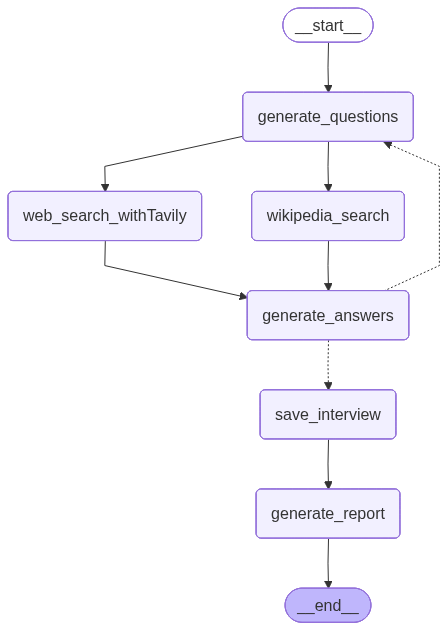

In [465]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

builder = StateGraph(interview_state)
# add nodes
builder.add_node('generate_questions', generate_questions) # ask question to an expert
builder.add_node('web_search_withTavily' , web_search_withTavily) # web search based on the questions (create context)
builder.add_node('wikipedia_search' , wikipedia_search) # wiki search based on the questions (create context)
builder.add_node('generate_answers' , generate_answers) # generate answers based on the questions asked
builder.add_node('save_interview' , save_interview) # save both questions and answers as an interview
builder.add_node('generate_report' , technical_writing) # create a report based on the context from web and wiki search

# add flow or adges
builder.set_entry_point('generate_questions')
builder.add_edge('generate_questions', 'web_search_withTavily') # using the questions websearch to get context
builder.add_edge('generate_questions', 'wikipedia_search') # using the questions wiki search to get context
builder.add_edge('web_search_withTavily', 'generate_answers') # join back to get answers
builder.add_edge('wikipedia_search', 'generate_answers') #  join back to get answers from the context
# save to interview if condition is met
builder.add_conditional_edges('generate_answers' , continue_task , ['save_interview','generate_questions'])
builder.add_edge('save_interview', 'generate_report') #  write a report based on the context
builder.add_edge('save_interview', END) #  end graph

#compile
interview_graph = builder.compile(checkpointer= checkpointer).with_config(run_name = "conduct interview")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

## Continue form original state:overallstate 
- get the analysts list and
- topic for the interview
- continue with ofiginal thread
  

In [466]:
state_new.values

{'topic': 'Best Language to speak',
 'subtopics': ['Economic and career advantages of learning English',
  'The cultural significance of Mandarin Chinese in global business',
  'Cognitive benefits of learning languages with complex grammatical structures'],
 'max_analyst': 3,
 'subtopic_feedback': 'Looks good! continue..',
 'human_analyst_feedback': 'Add in someone from a startup to add an entrepreneur perspective',
 'analysts': [AnalystList(analysts=[Analyst(name='Dr. Marcus Thorne', role='Global Labor Economist and Startup Founder', affiliation='Venture Growth Institute', description='Focuses on the ROI of linguistic proficiency in the startup ecosystem, analyzing how English fluency acts as a catalyst for venture capital acquisition and cross-border team scalability.'), Analyst(name='Dr. Elena Wei-Zhang', role='International Trade Strategist', affiliation='Global Business Council', description='Specializes in the intersection of cultural diplomacy and market entry, examining how Man

In [467]:
anlysts = state_new.values['analysts'][-1].analysts
anlysts[0]

Analyst(name='Dr. Marcus Thorne', role='Global Labor Economist and Startup Founder', affiliation='Venture Growth Institute', description='Focuses on the ROI of linguistic proficiency in the startup ecosystem, analyzing how English fluency acts as a catalyst for venture capital acquisition and cross-border team scalability.')

In [468]:
topic = state_new.values['topic']
topic

'Best Language to speak'

In [469]:
# prepare Human message for MessagesState providing the topic
Human_msg = [HumanMessage(content=f"so, where do you think the future is headed regarding this{topic}")]
interview = interview_graph.invoke({'topic' : topic , 'messages': Human_msg , 'analyst': anlysts[0] , 'max_turns' : 2 }, config )
interview

Answer:  content="The dominance of English is deeply entrenched as a language of innovation and progress, significantly influencing global economic and technological landscapes [1, 2, 3]. In the startup and technology sectors, English serves as a critical catalyst for venture capital acquisition and the scaling of cross-border teams. However, the reliance on English as the primary medium for innovation—ranging from the development of artificial intelligence to the expansion of the edtech industry—suggests that the future of global business will continue to be shaped by this linguistic hegemony [1, 2, 3]. While English facilitates a unified platform for communication and technical collaboration, such as the standards established by companies like Intel in the semiconductor industry, it also acts as a gatekeeper for global market participation [1, 2, 3]. The future is likely headed toward a continued reinforcement of English as the standard for high-tech and venture-backed enterprises, t

{'messages': [HumanMessage(content='so, where do you think the future is headed regarding thisBest Language to speak', additional_kwargs={}, response_metadata={}, id='fe4126fa-04d3-437d-ade8-293144c0bbd2'),
  AIMessage(content=[{'type': 'text', 'text': 'Hello, Dr. Thorne. I am Elias Vance, a Senior Strategic Analyst specializing in human capital infrastructure. It is a privilege to engage with you. Your work on the intersection of linguistic capital and venture liquidity has fundamentally shifted how we view the "cost of communication" in high-growth environments.\n\nTo open our discussion, let’s move past the standard narrative of English as a mere "lingua franca." \n\nDr. Thorne, when we analyze the velocity of capital, we often see a "linguistic premium" attached to founders who can articulate complex technical roadmaps in English. However, I want to probe deeper: **Do you believe that the dominance of English in the startup ecosystem is actually creating a "cognitive bottleneck" fo